/tmp/ipykernel_43390/2237563021.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = df['WQI'].fillna(method="ffill")
/home/ishaan/miniconda3/envs/python_lab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/ishaan/miniconda3/envs/python_lab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/ishaan/miniconda3/envs/python_lab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/ishaan/miniconda3/envs/python_lab/lib/python3.12/site-packages/statsmodels/tsa/sta

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
ARIMA -> RMSE: 17.20, MAE: 14.80, MAPE: 9.79%
SARIMA -> RMSE: 13.65, MAE: 11.31, MAPE: 7.65%
Prophet -> RMSE: 16.85, MAE: 14.98, MAPE: 10.04%
LSTM -> RMSE: 13.65, MAE: 11.81, MAPE: 7.99%


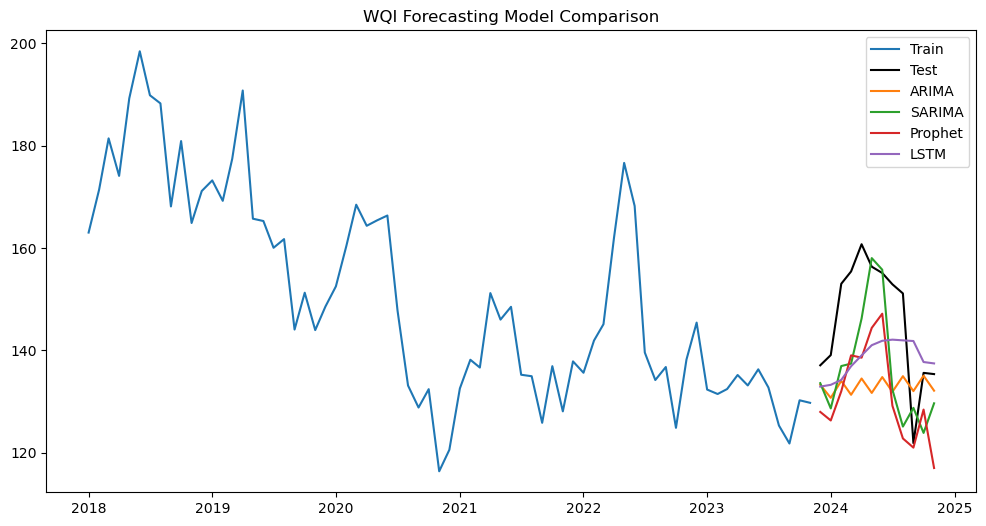

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1. Load Dataset
# -------------------------------
# Assuming you have a CSV with Date, WQI
df = pd.read_csv("cleaned_water_quality_with_date_and_wqi.csv")
df['Date'] = pd.to_datetime(df['Date'])
#print(df)
df = df.groupby('Date').mean() 
#print(df)# collapse duplicates
#df = df.asfreq('M')              # now it works
  # Monthly frequency (adjust if different)

series = df['WQI'].fillna(method="ffill")

# Train-test split (last 12 months as test)
train, test = series[:-12], series[-12:]

# -------------------------------
# 2. ARIMA Model
# -------------------------------
arima_model = ARIMA(train, order=(2,1,2)).fit()
arima_pred = arima_model.forecast(len(test))

# -------------------------------
# 3. SARIMA Model
# -------------------------------
sarima_model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12)).fit()
sarima_pred = sarima_model.forecast(len(test))

# -------------------------------
# 4. Prophet Model
# -------------------------------
prophet_df = train.reset_index()
prophet_df.columns = ["ds","y"]

prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet.fit(prophet_df)

future = pd.DataFrame({"ds": test.index})
forecast = prophet.predict(future)
prophet_pred = forecast['yhat'].values

# -------------------------------
# 5. LSTM Model
# -------------------------------
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(train.values.reshape(-1,1))

# Create sequences
def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 12
X_train, y_train = create_sequences(scaled_train, seq_len)

# Build LSTM
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len,1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

# Forecast with LSTM
scaled_all = scaler.transform(series.values.reshape(-1,1))
X_test, _ = create_sequences(scaled_all, seq_len)
lstm_pred_scaled = model.predict(X_test[-len(test):])
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# -------------------------------
# 6. Evaluation
# -------------------------------
def evaluate(true, pred, model_name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    print(f"{model_name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")
    return rmse, mae, mape

results = {}
results['ARIMA']   = evaluate(test, arima_pred, "ARIMA")
results['SARIMA']  = evaluate(test, sarima_pred, "SARIMA")
results['Prophet'] = evaluate(test, prophet_pred, "Prophet")
results['LSTM']    = evaluate(test, lstm_pred.flatten(), "LSTM")

# -------------------------------
# 7. Visualization
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="black")
plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, sarima_pred, label="SARIMA")
plt.plot(test.index, prophet_pred, label="Prophet")
plt.plot(test.index, lstm_pred, label="LSTM")
plt.legend()
plt.title("WQI Forecasting Model Comparison")
plt.show()


In [2]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.7 MB/s  0:00:00 10.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]


In [4]:
# ARIMA forecast with intervals
arima_res = arima_model.get_forecast(steps=len(test))
arima_pred = arima_res.predicted_mean
arima_ci = arima_res.conf_int(alpha=0.05)   # 95% CI

# SARIMA forecast with intervals
sarima_res = sarima_model.get_forecast(steps=len(test))
sarima_pred = sarima_res.predicted_mean
sarima_ci = sarima_res.conf_int(alpha=0.05)


In [5]:
forecast = prophet.predict(future)
prophet_pred = forecast['yhat'].values
prophet_ci = forecast[['yhat_lower', 'yhat_upper']]


In [6]:
from tensorflow.keras.layers import Dropout
import tensorflow as tf

# Build LSTM with Dropout
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len,1), dropout=0.2, recurrent_dropout=0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

# MC Dropout predictions (e.g. 50 runs)
preds = []
for _ in range(50):
    preds.append(model(X_test[-len(test):], training=True).numpy())
preds = np.array(preds).squeeze()

lstm_pred_mean = scaler.inverse_transform(preds.mean(axis=0).reshape(-1,1)).flatten()
lstm_pred_lower = scaler.inverse_transform(np.percentile(preds, 10, axis=0).reshape(-1,1)).flatten()
lstm_pred_upper = scaler.inverse_transform(np.percentile(preds, 90, axis=0).reshape(-1,1)).flatten()


/home/ishaan/miniconda3/envs/python_lab/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


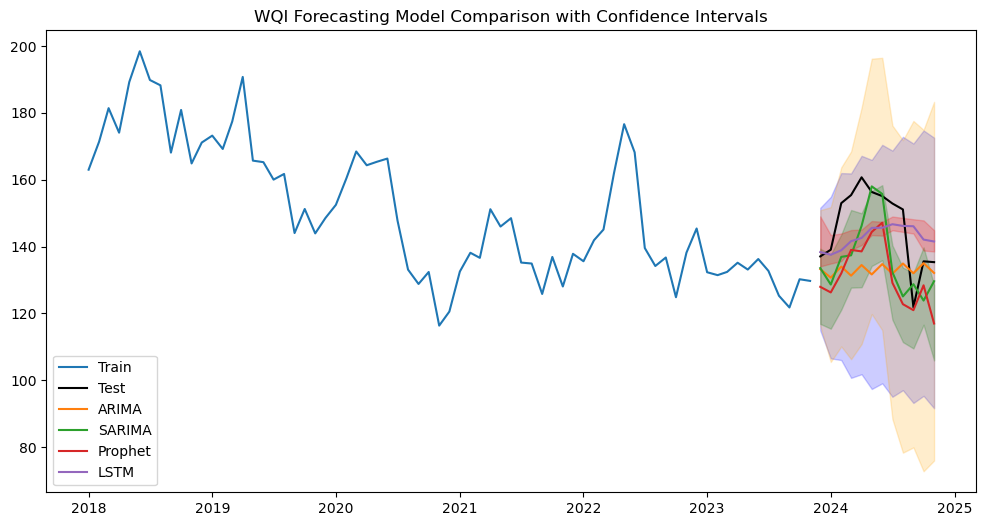

In [7]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="black")

# ARIMA
plt.plot(test.index, arima_pred, label="ARIMA")
plt.fill_between(test.index, arima_ci.iloc[:,0], arima_ci.iloc[:,1], color="blue", alpha=0.2)

# SARIMA
plt.plot(test.index, sarima_pred, label="SARIMA")
plt.fill_between(test.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color="orange", alpha=0.2)

# Prophet
plt.plot(test.index, prophet_pred, label="Prophet")
plt.fill_between(test.index, prophet_ci['yhat_lower'], prophet_ci['yhat_upper'], color="green", alpha=0.2)

# LSTM
plt.plot(test.index, lstm_pred_mean, label="LSTM")
plt.fill_between(test.index, lstm_pred_lower, lstm_pred_upper, color="red", alpha=0.2)

plt.legend()
plt.title("WQI Forecasting Model Comparison with Confidence Intervals")
plt.show()


In [8]:
# -------------------------------
# Collect Confidence Intervals
# -------------------------------

# ARIMA
arima_res = arima_model.get_forecast(steps=len(test))
arima_pred = arima_res.predicted_mean
arima_ci = arima_res.conf_int(alpha=0.05)  # 95%

# SARIMA
sarima_res = sarima_model.get_forecast(steps=len(test))
sarima_pred = sarima_res.predicted_mean
sarima_ci = sarima_res.conf_int(alpha=0.05)

# Prophet
forecast = prophet.predict(future)
prophet_pred = forecast['yhat'].values
prophet_ci = forecast[['yhat_lower', 'yhat_upper']]

# LSTM (using dropout approach from before)
preds = []
for _ in range(30):   # 30 MC runs for CI
    preds.append(model(X_test[-len(test):], training=True).numpy())
preds = np.array(preds).squeeze()

lstm_pred_mean = scaler.inverse_transform(preds.mean(axis=0).reshape(-1,1)).flatten()
lstm_pred_lower = scaler.inverse_transform(np.percentile(preds, 10, axis=0).reshape(-1,1)).flatten()
lstm_pred_upper = scaler.inverse_transform(np.percentile(preds, 90, axis=0).reshape(-1,1)).flatten()

# -------------------------------
# Build Comparison Table
# -------------------------------
ci_table = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,

    "ARIMA_Pred": arima_pred.values,
    "ARIMA_Lower": arima_ci.iloc[:,0].values,
    "ARIMA_Upper": arima_ci.iloc[:,1].values,

    "SARIMA_Pred": sarima_pred.values,
    "SARIMA_Lower": sarima_ci.iloc[:,0].values,
    "SARIMA_Upper": sarima_ci.iloc[:,1].values,

    "Prophet_Pred": prophet_pred,
    "Prophet_Lower": prophet_ci['yhat_lower'].values,
    "Prophet_Upper": prophet_ci['yhat_upper'].values,

    "LSTM_Pred": lstm_pred_mean,
    "LSTM_Lower": lstm_pred_lower,
    "LSTM_Upper": lstm_pred_upper,
})

# Display nicely
pd.set_option("display.max_columns", None)
print(ci_table.round(2))


         Date  Actual  ARIMA_Pred  ARIMA_Lower  ARIMA_Upper  SARIMA_Pred  \
0  2023-12-01  137.08      133.27       114.92       151.62       133.59   
1  2024-01-01  139.07      130.72       106.57       154.88       128.65   
2  2024-02-01  153.01      134.03       106.07       161.99       136.93   
3  2024-03-01  155.41      131.32       100.74       161.90       137.40   
4  2024-04-01  160.73      134.49       101.83       167.16       146.21   
5  2024-05-01  156.35      131.68        97.41       165.95       158.02   
6  2024-06-01  155.11      134.78        99.11       170.45       155.75   
7  2024-07-01  152.90      131.90        95.08       168.72       132.33   
8  2024-08-01  151.12      134.95        97.06       172.84       125.11   
9  2024-09-01  121.88      132.04        93.23       170.84       128.76   
10 2024-10-01  135.60      135.05        95.36       174.75       123.86   
11 2024-11-01  135.36      132.12        91.65       172.59       129.65   

    SARIMA_

In [9]:
# -------------------------------
# Model Evaluation
# -------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_with_ci(true, pred, lower, upper, model_name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    avg_ci_width = np.mean(upper - lower)
    return [rmse, mae, mape, avg_ci_width]

comparison = pd.DataFrame([
    evaluate_with_ci(ci_table["Actual"], ci_table["ARIMA_Pred"], 
                     ci_table["ARIMA_Lower"], ci_table["ARIMA_Upper"], "ARIMA"),
    evaluate_with_ci(ci_table["Actual"], ci_table["SARIMA_Pred"], 
                     ci_table["SARIMA_Lower"], ci_table["SARIMA_Upper"], "SARIMA"),
    evaluate_with_ci(ci_table["Actual"], ci_table["Prophet_Pred"], 
                     ci_table["Prophet_Lower"], ci_table["Prophet_Upper"], "Prophet"),
    evaluate_with_ci(ci_table["Actual"], ci_table["LSTM_Pred"], 
                     ci_table["LSTM_Lower"], ci_table["LSTM_Upper"], "LSTM"),
], columns=["RMSE","MAE","MAPE (%)","Avg_CI_Width"], 
   index=["ARIMA","SARIMA","Prophet","LSTM"])

print(comparison.round(3))


           RMSE     MAE  MAPE (%)  Avg_CI_Width
ARIMA    17.204  14.798     9.789        66.219
SARIMA   13.648  11.312     7.653        76.125
Prophet  16.853  14.985    10.042        22.239
LSTM     11.678   9.583     6.639         5.970


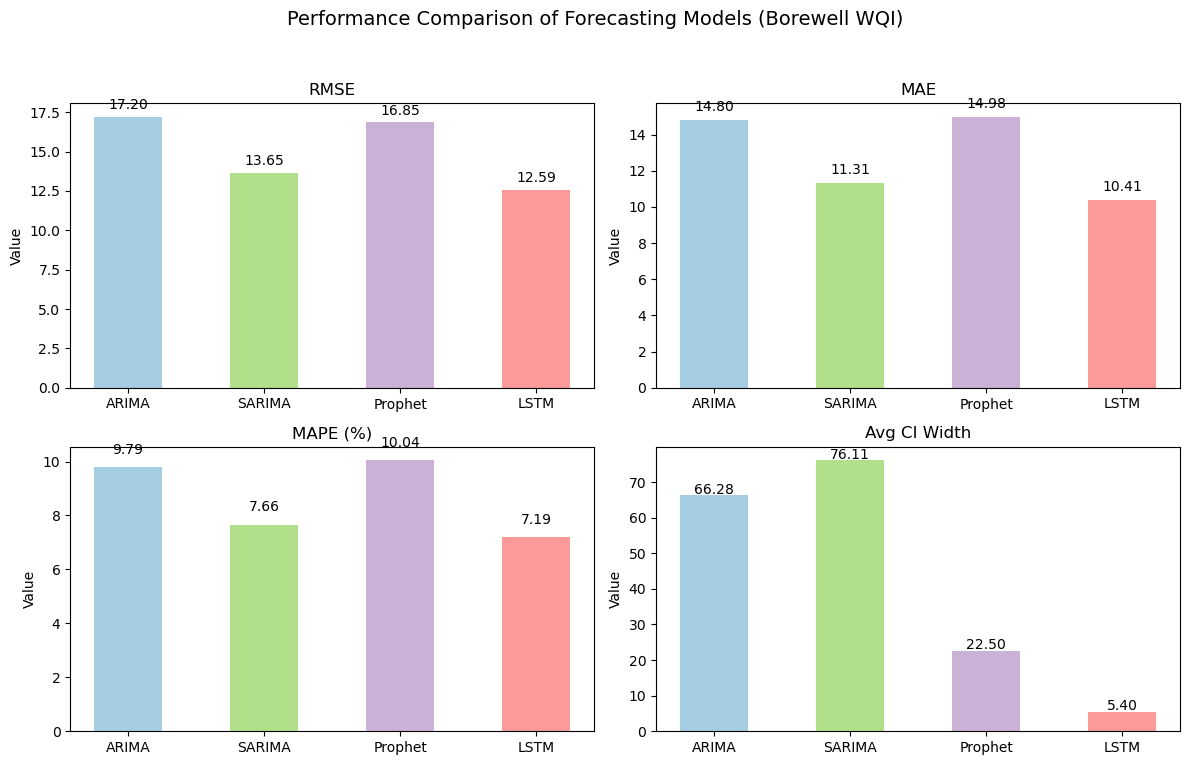

In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ARIMA", "SARIMA", "Prophet", "LSTM"]

rmse = [17.203, 13.651, 16.853, 12.589]
mae  = [14.797, 11.314, 14.985, 10.406]
mape = [9.788, 7.655, 10.042, 7.191]
ci_width = [66.283, 76.111, 22.501, 5.399]

metrics = [rmse, mae, mape, ci_width]
metric_names = ["RMSE", "MAE", "MAPE (%)", "Avg CI Width"]

x = np.arange(len(models))
width = 0.2

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric, name in zip(axs.flat, metrics, metric_names):
    ax.bar(x, metric, color = ["#a6cee3", "#b2df8a", "#cab2d6","#fb9a99"]  , width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title(name)
    ax.set_ylabel("Value")

    for i, v in enumerate(metric):
        ax.text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.suptitle("Performance Comparison of Forecasting Models (Borewell WQI)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()
